# Labor Market Intelligence — notebook tổng hợp

**Câu hỏi:** Thị trường IT/Data Việt Nam 2026 cần kỹ năng gì, và cấp bậc/kỹ năng nào đi kèm dải lương cao?

| | Câu hỏi | Phương pháp |
|---|---|---|
| Q1 | Kỹ năng nào hay đi cùng nhau? | Apriori, train/test theo thời gian |
| Q2 | Tin tự nhóm thành bao nhiêu nhóm nghề? | Hierarchical clustering (Jaccard, weighted) + purity |
| Q3 | Cấp bậc/kỹ năng/địa điểm nào đi kèm lương cao? | Decision Tree (nested CV) + phân tích thiên lệch |

Notebook gọi lại đúng các hàm trong `src/models/` và **kiểm tra kết quả khớp các báo cáo** trong `reports/`. Cuối notebook xuất `reports/key_numbers.json` — mọi con số trên slide lấy từ file này.

**Dữ liệu cần có:** `data/processed/jobs_clean.parquet` và `data/processed/skill_matrix.parquet` (tải từ Drive, hoặc chạy `python scripts/run_pipeline.py skills`). Hash phải khớp `docs/MANIFEST.json`.

Notebook chỉ hiển thị số liệu tổng hợp, **không** in nguyên văn JD (cam kết ToS, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Chạy được dù mở notebook từ thư mục gốc repo hay từ notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, load_data, save_figure, salary_tertiles, skill_share

# load_data() kiểm SHA-256 của jobs_clean + skill_matrix với docs/MANIFEST.json, lệch thì dừng
jobs, skills = load_data()
print(f"{len(jobs)} tin, {skills.shape[1]} kỹ năng — hash khớp docs/MANIFEST.json")

import json
from collections import Counter

from src.models import apriori as ap
from src.models import classification as clf
from src.models.bias_analysis import compare_groups
from src.models.clustering import calculate_purity_fmeasure
from src.models.features import _sha256, load_and_verify_data

KEY = {}  # số liệu cho slide

# Kiểm hash cả 4 file đã freeze
manifest = {e["filename"]: e["sha256"] for e in json.load(open(ROOT / "docs" / "MANIFEST.json"))["files"]}
for name, expected in manifest.items():
    ok = _sha256(ROOT / "data" / "processed" / name) == expected
    print(f"{'✓' if ok else '✗'} {name}")
    assert ok, f"{name} lệch MANIFEST"

688 tin, 100 kỹ năng — hash khớp docs/MANIFEST.json
✓ cluster_labels.csv
✓ jobs_clean.parquet
✓ rules_train.csv
✓ skill_matrix.parquet


## 1. Dữ liệu

In [2]:
raw_jobs, raw_skills = load_and_verify_data()  # bản gốc: skill_matrix 677 dòng (đã bỏ tin 0 kỹ năng)
cluster_labels = pd.read_csv(ROOT / "data" / "processed" / "cluster_labels.csv")
KEY["data"] = {
    "n_jobs": len(jobs),
    "crawl_date": "2026-09-29",
    "n_jobs_with_skills": len(raw_skills),
    "n_skills_in_matrix": raw_skills.shape[1] - 1,
    "n_jobs_clustered": len(cluster_labels),
    "n_jobs_with_salary": int(jobs["has_salary"].sum()),
    "pct_with_salary": round(float(jobs["has_salary"].mean()) * 100, 1),
    "posted_from": f"{jobs['posted_date'].min():%Y-%m-%d}",
    "posted_to": f"{jobs['posted_date'].max():%Y-%m-%d}",
}
# A7 đọc từ báo cáo sinh bởi scripts/verify_a7.py (bộ kiểm tra độc lập seed 2026)
import re
a7 = (ROOT / "reports" / "A7_evaluation_seed2026.md").read_text(encoding="utf-8")
KEY["data"]["skill_dict_coverage_a7_pct"] = float(re.search(r"Độ phủ \(micro\): ([\d.]+)%", a7).group(1))
pd.Series(KEY["data"])

n_jobs                               688
crawl_date                    2026-09-29
n_jobs_with_skills                   677
n_skills_in_matrix                   100
n_jobs_clustered                     548
n_jobs_with_salary                   172
pct_with_salary                     25.0
posted_from                   2026-08-10
posted_to                     2026-09-29
skill_dict_coverage_a7_pct          72.6
dtype: object

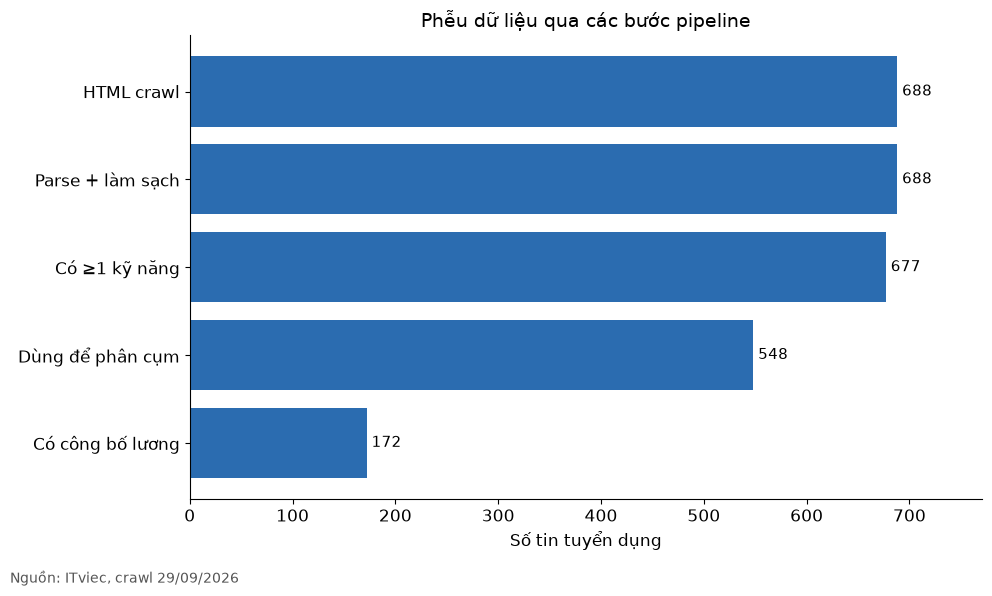

In [3]:
fig = FIGURES["pipeline_funnel"](jobs, skills)

## 2. EDA — điểm chính

Đầy đủ 14 hình ở `eda_full.ipynb`.

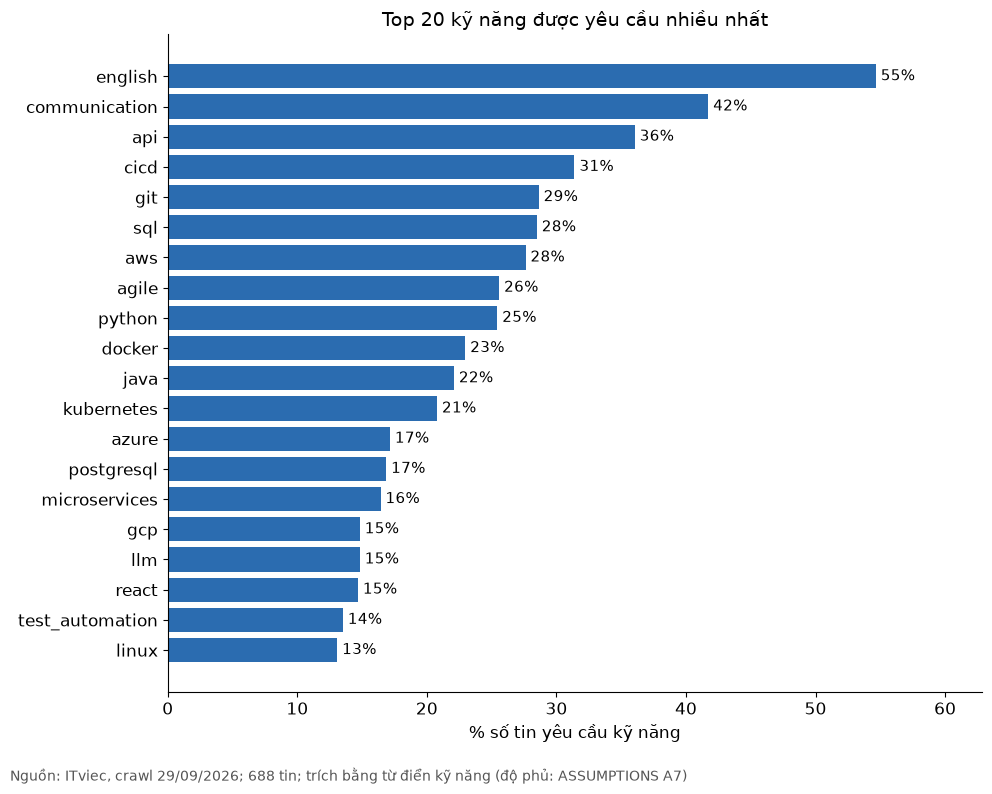

In [4]:
fig = FIGURES["top_skills"](jobs, skills)

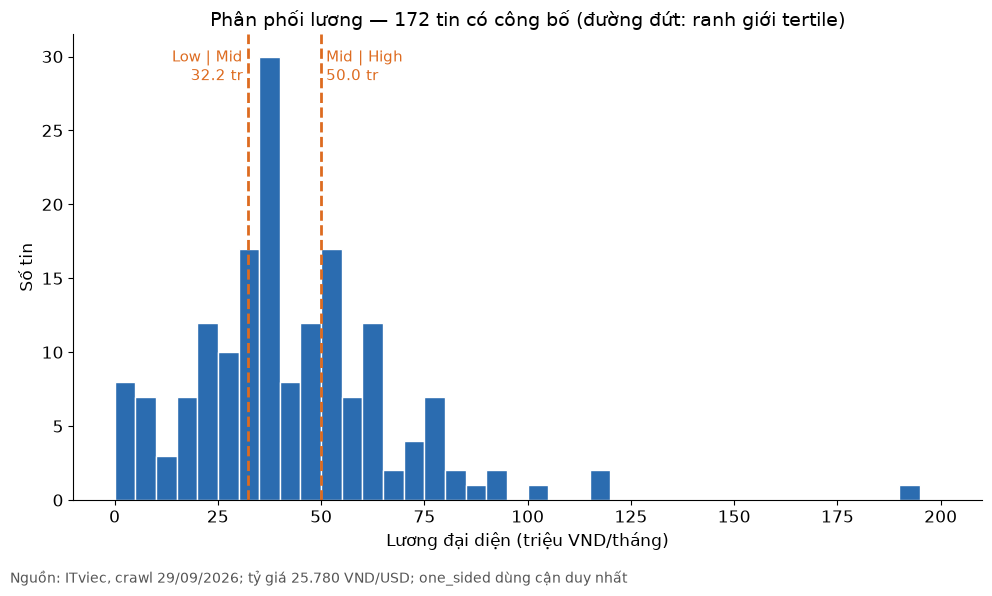

In [5]:
fig = FIGURES["salary_distribution"](jobs, skills)

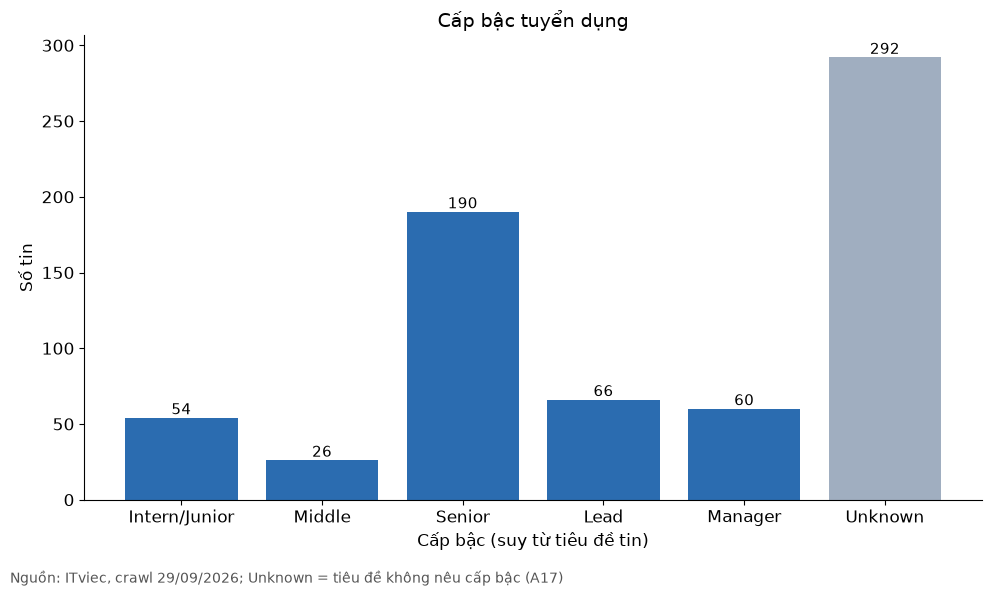

In [6]:
fig = FIGURES["levels"](jobs, skills)

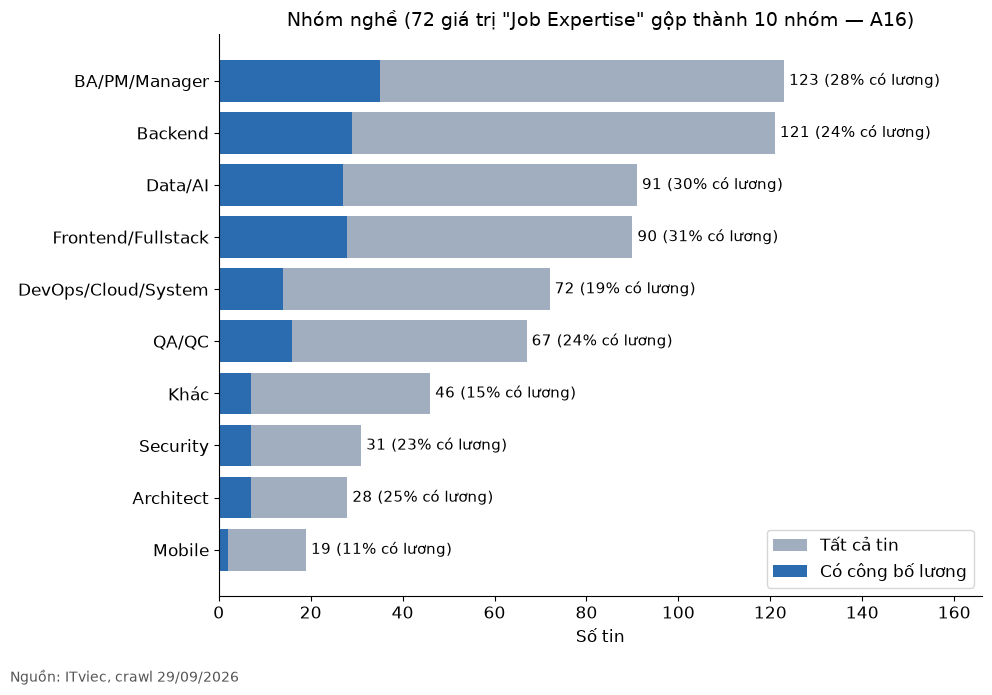

In [7]:
fig = FIGURES["expertise_groups"](jobs, skills)

In [8]:
share = skill_share(skills)
paid = jobs.loc[jobs["has_salary"], "salary_mid"]
KEY["eda"] = {
    "top10_skills_pct": {k: round(float(v) * 100, 1) for k, v in share.head(10).items()},
    "salary_median_million_vnd": round(float(paid.median()), 1),
    "currency_counts": jobs.loc[jobs["has_salary"], "currency_original"].value_counts().to_dict(),
    "pct_level_unknown": round(float((jobs["level_group"] == "Unknown").mean()) * 100, 1),
    "location_counts": {c: int(jobs[c].sum()) for c in ["loc_hcm", "loc_hn", "loc_dn", "loc_other"]},
}
KEY["eda"]

{'top10_skills_pct': {'english': 54.7,
  'communication': 41.7,
  'api': 36.0,
  'cicd': 31.4,
  'git': 28.6,
  'sql': 28.5,
  'aws': 27.6,
  'agile': 25.6,
  'python': 25.4,
  'docker': 23.0},
 'salary_median_million_vnd': 38.7,
 'currency_counts': {'USD': 151, 'VND': 21},
 'pct_level_unknown': 42.4,
 'location_counts': {'loc_hcm': 425,
  'loc_hn': 288,
  'loc_dn': 34,
  'loc_other': 3}}

## 3. Q1 — Luật kết hợp kỹ năng (Apriori)

Chia 70% tin cũ làm train, 30% tin mới làm test (theo `posted_date`). Khai phá trên train với lift > 1,2 và confidence ≥ 0,5, rồi đo lại từng luật trên test để xem luật có còn đúng không (rule drift).

In [9]:
df = raw_skills.merge(raw_jobs[["job_id", "posted_date"]], on="job_id")
df["posted_date"] = pd.to_datetime(df["posted_date"])
feature_cols = [c for c in df.columns if c not in ("job_id", "posted_date")]
train_part, test_part = ap.chronological_split(df, train_frac=0.7)
train_df, test_df = train_part[feature_cols], test_part[feature_cols]

train_rules, support_counts = ap.run_apriori(train_df, min_supports=[0.03, 0.04, 0.05, 0.06, 0.10],
                                             min_lift=1.2, min_confidence=0.5)
ms_used = float(train_rules["min_support_used"].iloc[0])
print(f"Train {len(train_df)} / Test {len(test_df)} tin")
print("Số luật theo min_support:", support_counts, "→ chọn", ms_used, f"({len(train_rules)} luật)")

top = ap.dedup_by_itemset(train_rules, top_n=10)
test_res = ap.evaluate_rules_on_test(top, test_df)
rules_table = pd.DataFrame([{
    "Luật": f"{ap.format_itemset(r.antecedents)} → {ap.format_itemset(r.consequents)}",
    "Train conf": round(r.confidence, 3), "Train lift": round(r.lift, 3),
    "Test conf": round(test_res[i]["test_confidence"], 3), "Test lift": round(test_res[i]["test_lift"], 3),
} for i, r in top.iterrows()])
rules_table

Train 473 / Test 204 tin
Số luật theo min_support: {0.03: 2608, 0.04: 1098, 0.05: 477, 0.06: 197, 0.1: 35} → chọn 0.1 (35 luật)


,Luật,Train conf,Train lift,Test conf,Test lift
0,spring → java,1.000,4.683,1.000,4.000
1,kubernetes → docker,0.656,3.200,0.723,2.419
2,gcp → aws,0.812,2.999,0.939,3.091
3,microservices → kubernetes,0.608,2.994,0.441,1.915
4,azure → aws,0.744,2.749,0.778,2.559
5,"aws, git → cicd",0.787,2.498,0.966,2.940
6,docker → cicd,0.742,2.356,0.656,1.997
7,"api, git → cicd",0.700,2.222,0.682,2.076
8,git → cicd,0.690,2.190,0.691,2.104
9,kubernetes → aws,0.573,2.117,0.638,2.100


In [10]:
# Kiểm: khớp reports/rules_eval.md (sinh bởi src/models/apriori.py)
rules_md = (ROOT / "reports" / "rules_eval.md").read_text(encoding="utf-8")
assert f"Train: {len(train_df)} bản ghi" in rules_md and f"tìm được {len(train_rules)} luật" in rules_md
first = top.iloc[0]
assert f"| {ap.format_itemset(first.antecedents)} | {ap.format_itemset(first.consequents)} | {first.support:.3f} |" in rules_md
print("✓ khớp reports/rules_eval.md")

hold = sum(1 for i in top.index if test_res[i]["test_lift"] > 1.2 and test_res[i]["test_confidence"] >= 0.5)
KEY["q1_rules"] = {
    "n_train": len(train_df), "n_test": len(test_df), "min_support": ms_used, "n_rules": len(train_rules),
    "top_rules_hold_on_test": f"{hold}/{len(top)}",
    "top_rules": rules_table.head(5).to_dict("records"),
}
print(f"{hold}/{len(top)} luật top vẫn đạt lift > 1,2 và confidence ≥ 0,5 trên test")

✓ khớp reports/rules_eval.md
9/10 luật top vẫn đạt lift > 1,2 và confidence ≥ 0,5 trên test


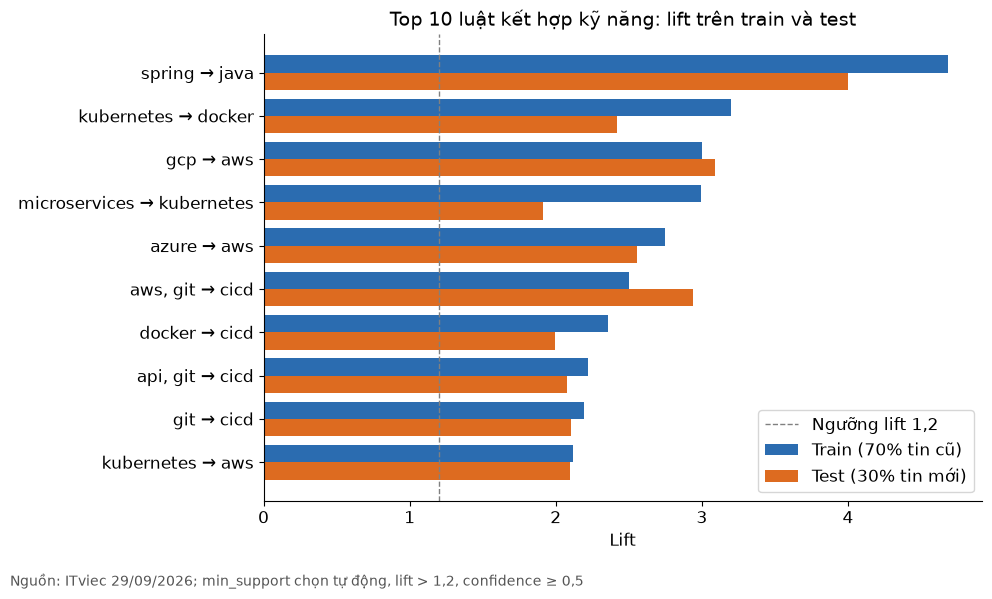

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rules_table))
ax.barh(y - 0.2, rules_table["Train lift"], height=0.4, color="#2b6cb0", label="Train (70% tin cũ)")
ax.barh(y + 0.2, rules_table["Test lift"], height=0.4, color="#dd6b20", label="Test (30% tin mới)")
ax.axvline(1.2, color="grey", linestyle="--", linewidth=1, label="Ngưỡng lift 1,2")
ax.set_yticks(y, rules_table["Luật"])
ax.invert_yaxis()
ax.set_xlabel("Lift")
ax.set_title("Top 10 luật kết hợp kỹ năng: lift trên train và test")
ax.legend(loc="lower right")
fig.text(0.01, 0.01, "Nguồn: ITviec 29/09/2026; min_support chọn tự động, lift > 1,2, confidence ≥ 0,5",
         fontsize=10, color="#555555")
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(ROOT / "reports" / "figures" / "model_rules_train_test.png", dpi=150)

**Đọc kết quả:** đa số luật top giữ được trên tập test (số in ở trên). Lưu ý dữ liệu là snapshot tin còn tuyển, nên train/test khác nhau về *độ tuổi của tin* chứ không phải thay đổi thị trường dài hạn.

## 4. Q2 — Phân cụm tin theo kỹ năng

Hierarchical clustering, khoảng cách Jaccard, weighted linkage; chọn k theo silhouette với cụm nhỏ nhất ≥ 15 tin (`src/models/clustering.py`). Đánh giá bằng purity so với 10 nhóm nghề gộp từ "Job Expertise" (A16).

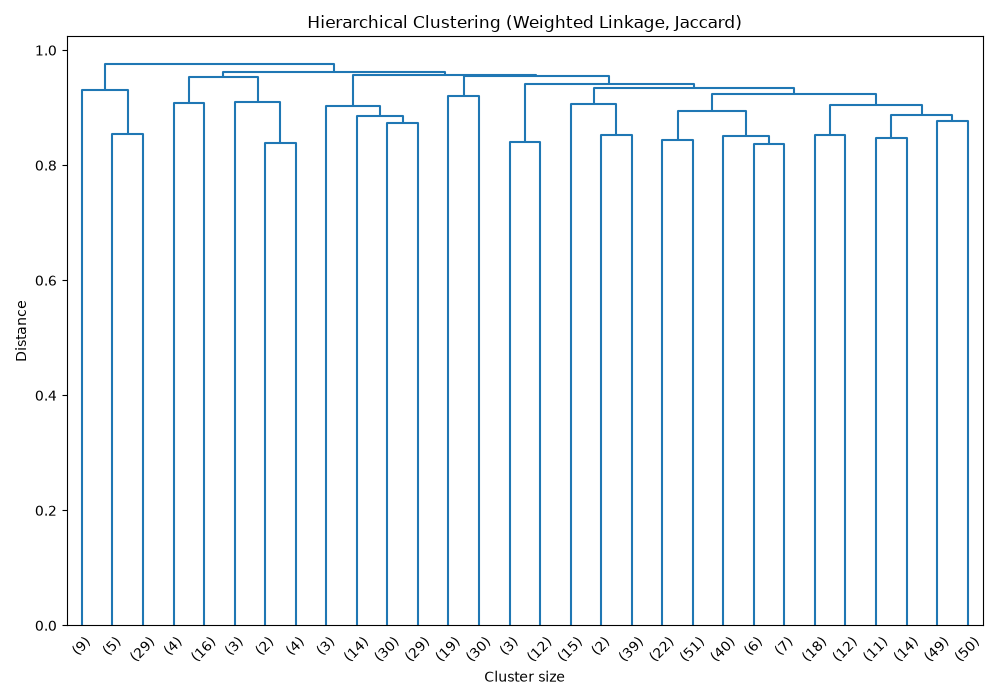

In [12]:
display(Image(filename=str(ROOT / "reports" / "figures" / "dendrogram.png"), width=800))

In [13]:
merged = cluster_labels.merge(jobs[["expertise_group"]], left_on="job_id", right_index=True)
crosstab = pd.crosstab(merged["cluster"], merged["expertise_group"])
purity, baseline_purity, f_measure = calculate_purity_fmeasure(crosstab)
sizes = cluster_labels["cluster"].value_counts().sort_index()

purity_md = (ROOT / "reports" / "purity_report.md").read_text(encoding="utf-8")
assert f"**Purity:** {purity:.4f}" in purity_md, "Không khớp reports/purity_report.md"
sil = float(purity_md.split("silhouette = ")[1].split()[0])
print("✓ khớp reports/purity_report.md")
print(f"k = {len(sizes)}, kích thước cụm {sizes.to_dict()}, silhouette {sil:.3f}")
print(f"Purity {purity:.3f} (baseline {baseline_purity:.3f}), F-measure {f_measure:.3f}")
KEY["q2_clustering"] = {
    "k": int(len(sizes)), "cluster_sizes": {int(k): int(v) for k, v in sizes.items()},
    "silhouette": round(sil, 3), "purity": round(float(purity), 3),
    "baseline_purity": round(float(baseline_purity), 3), "f_measure": round(float(f_measure), 3),
    "pct_jobs_in_largest_cluster": round(float(sizes.max() / sizes.sum()) * 100, 1),
}
crosstab

✓ khớp reports/purity_report.md
k = 4, kích thước cụm {1: 43, 2: 29, 3: 76, 4: 400}, silhouette 0.048
Purity 0.334 (baseline 0.208), F-measure 0.323


expertise_group,Architect,BA/PM/Manager,Backend,Data/AI,DevOps/Cloud/System,Frontend/Fullstack,Khác,Mobile,QA/QC,Security
cluster,,,,,,,,,,
1,0,22,3,12,2,0,2,0,0,2
2,1,4,3,18,1,0,0,0,2,0
3,3,7,3,38,10,3,3,2,1,6
4,22,27,105,15,51,85,17,16,51,11


✓ top 5 kỹ năng mỗi cụm khớp reports/purity_report.md


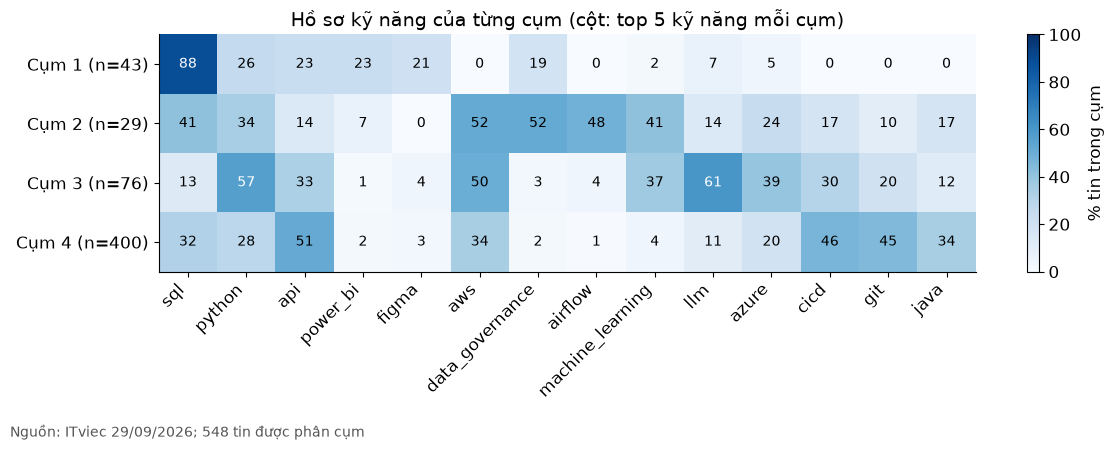

In [14]:
# Hồ sơ kỹ năng từng cụm — dùng đúng bộ kỹ năng mà clustering.py giữ lại
# (bỏ kỹ năng mềm/quản lý, kỹ năng > 40% số tin hoặc < 10 tin), cột = hợp top 5 kỹ năng mỗi cụm
from src.models.clustering import FREQUENT_SKILL_RATIO, MANUAL_DROPS, RARE_SKILL_MIN
sm = raw_skills.set_index("job_id").sort_index(axis=1)  # như clustering.py
kept = [s for s in sm.columns if sm[s].mean() <= FREQUENT_SKILL_RATIO and sm[s].sum() >= RARE_SKILL_MIN
        and s not in MANUAL_DROPS]
in_clusters = sm.loc[cluster_labels["job_id"], kept]
by_cluster = in_clusters.groupby(cluster_labels["cluster"].values).mean()
cols = []
for c in by_cluster.index:
    # cùng kiểu sort với clustering.py; lưu ý có hoà ở vị trí thứ 5 (vd. cụm 2: sql = etl = 41%)
    top5 = by_cluster.loc[c].sort_values(ascending=False).head(5)
    line = ", ".join(f"{s} ({v:.0%})" for s, v in top5.items())
    assert f"**Cụm {c}:** {line}" in purity_md, f"Top 5 cụm {c} không khớp purity_report.md"
    cols += [s for s in top5.index if s not in cols]
print("✓ top 5 kỹ năng mỗi cụm khớp reports/purity_report.md")
profile = by_cluster[cols] * 100
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(profile.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(profile)), [f"Cụm {c} (n={sizes[c]})" for c in profile.index])
for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        v = profile.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=10, color="white" if v > 55 else "black")
fig.colorbar(im, ax=ax, label="% tin trong cụm")
ax.set_title("Hồ sơ kỹ năng của từng cụm (cột: top 5 kỹ năng mỗi cụm)")
fig.text(0.01, 0.01, f"Nguồn: ITviec 29/09/2026; {len(cluster_labels)} tin được phân cụm", fontsize=10, color="#555555")
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(ROOT / "reports" / "figures" / "model_cluster_profiles.png", dpi=150)

**Đọc kết quả:** silhouette gần 0 và một cụm lớn chiếm phần đông số tin → tổ hợp kỹ năng trên ITviec **không tách thành nhóm nghề rõ ràng**. Các cụm nhỏ có đặc trưng rõ hơn (xem hồ sơ kỹ năng). Đây là kết quả, không phải lỗi — xem phần hạn chế trong `reports/purity_report.md`.

## 5. Q3 — Decision Tree phân lớp lương

Chỉ dùng tin có công bố lương; nhãn Low/Mid/High chia theo tertile (DECISIONS Mốc 2). Feature: kỹ năng, cấp bậc (suy từ tiêu đề), địa điểm. Đánh giá bằng nested CV (ngoài 5 fold, trong 3 fold chọn tham số), dự đoán out-of-fold.

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier

X, y, bins = clf.build_dataset(raw_jobs, raw_skills)
oof, folds = clf.nested_cv(X, y)          # ~vài giây
y_arr = y.to_numpy(dtype=object)
acc = accuracy_score(y_arr, oof)
ci_low, ci_high = clf.bootstrap_ci(y_arr, oof)
baseline = y.value_counts().max() / len(y)
macro_f1 = f1_score(y_arr, oof, average="macro")
cm = confusion_matrix(y_arr, oof, labels=clf.CLASSES)

report = (ROOT / "reports" / "classification_report.md").read_text(encoding="utf-8")
assert f"**Accuracy:** {acc:.4f}" in report, "Không khớp reports/classification_report.md"
print("✓ khớp reports/classification_report.md")
print(f"{len(X)} tin, {X.shape[1]} feature; lớp {y.value_counts().reindex(clf.CLASSES).to_dict()}")
print(f"Ranh giới tertile: {bins[1]:.1f} / {bins[2]:.1f} triệu VND/tháng")
print(f"Accuracy OOF {acc:.3f} (95% CI {ci_low:.3f}–{ci_high:.3f}) | baseline {baseline:.3f} | macro-F1 {macro_f1:.3f}")
folds

✓ khớp reports/classification_report.md
172 tin, 80 feature; lớp {'Low': 60, 'Mid': 55, 'High': 57}
Ranh giới tertile: 32.2 / 50.0 triệu VND/tháng
Accuracy OOF 0.529 (95% CI 0.453–0.605) | baseline 0.349 | macro-F1 0.506


,fold,max_depth,min_samples_leaf,inner_cv_accuracy,fold_accuracy
0,1,3,5,0.4957,0.4571
1,2,4,10,0.5248,0.4286
2,3,3,5,0.4928,0.5588
3,4,4,5,0.4493,0.5882
4,5,4,5,0.4783,0.6176


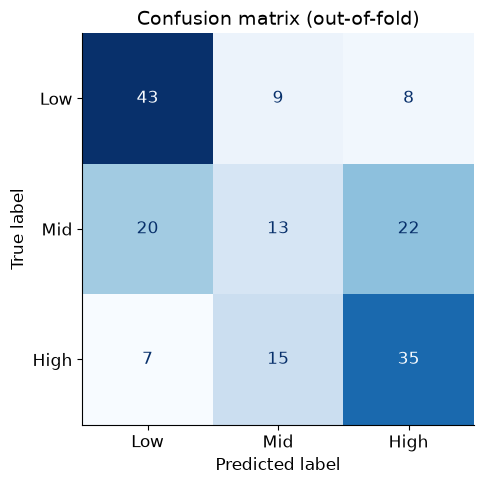

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=clf.CLASSES).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion matrix (out-of-fold)")
fig.tight_layout()

Recall từng lớp: {'Low': 0.717, 'Mid': 0.236, 'High': 0.614}


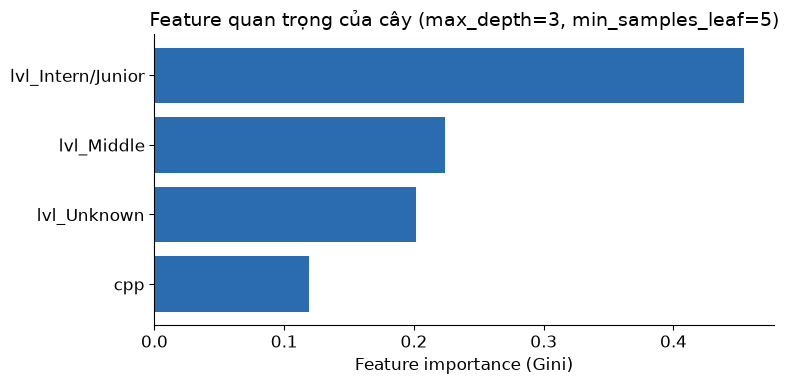

In [17]:
params = clf.choose_final_params(list(zip(folds["max_depth"], folds["min_samples_leaf"])))
model = DecisionTreeClassifier(criterion="gini", max_depth=int(params[0]), min_samples_leaf=int(params[1]),
                               random_state=clf.RANDOM_STATE).fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance[importance > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2b6cb0")
ax.set_xlabel("Feature importance (Gini)")
ax.set_title(f"Feature quan trọng của cây (max_depth={params[0]}, min_samples_leaf={params[1]})")
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "model_feature_importance.png", dpi=150)

recall = {c: round(float(cm[i, i] / cm[i].sum()), 3) for i, c in enumerate(clf.CLASSES)}
KEY["q3_tree"] = {
    "n_jobs": int(len(X)), "n_features": int(X.shape[1]),
    "class_counts": y.value_counts().reindex(clf.CLASSES).to_dict(),
    "tertile_bounds_million_vnd": [round(float(bins[1]), 1), round(float(bins[2]), 1)],
    "accuracy": round(float(acc), 3), "accuracy_ci95": [round(float(ci_low), 3), round(float(ci_high), 3)],
    "baseline": round(float(baseline), 3), "macro_f1": round(float(macro_f1), 3),
    "recall_by_class": recall,
    "final_params": {"max_depth": int(params[0]), "min_samples_leaf": int(params[1])},
    "feature_importance": importance.sort_values(ascending=False).round(3).to_dict(),
}
print("Recall từng lớp:", recall)

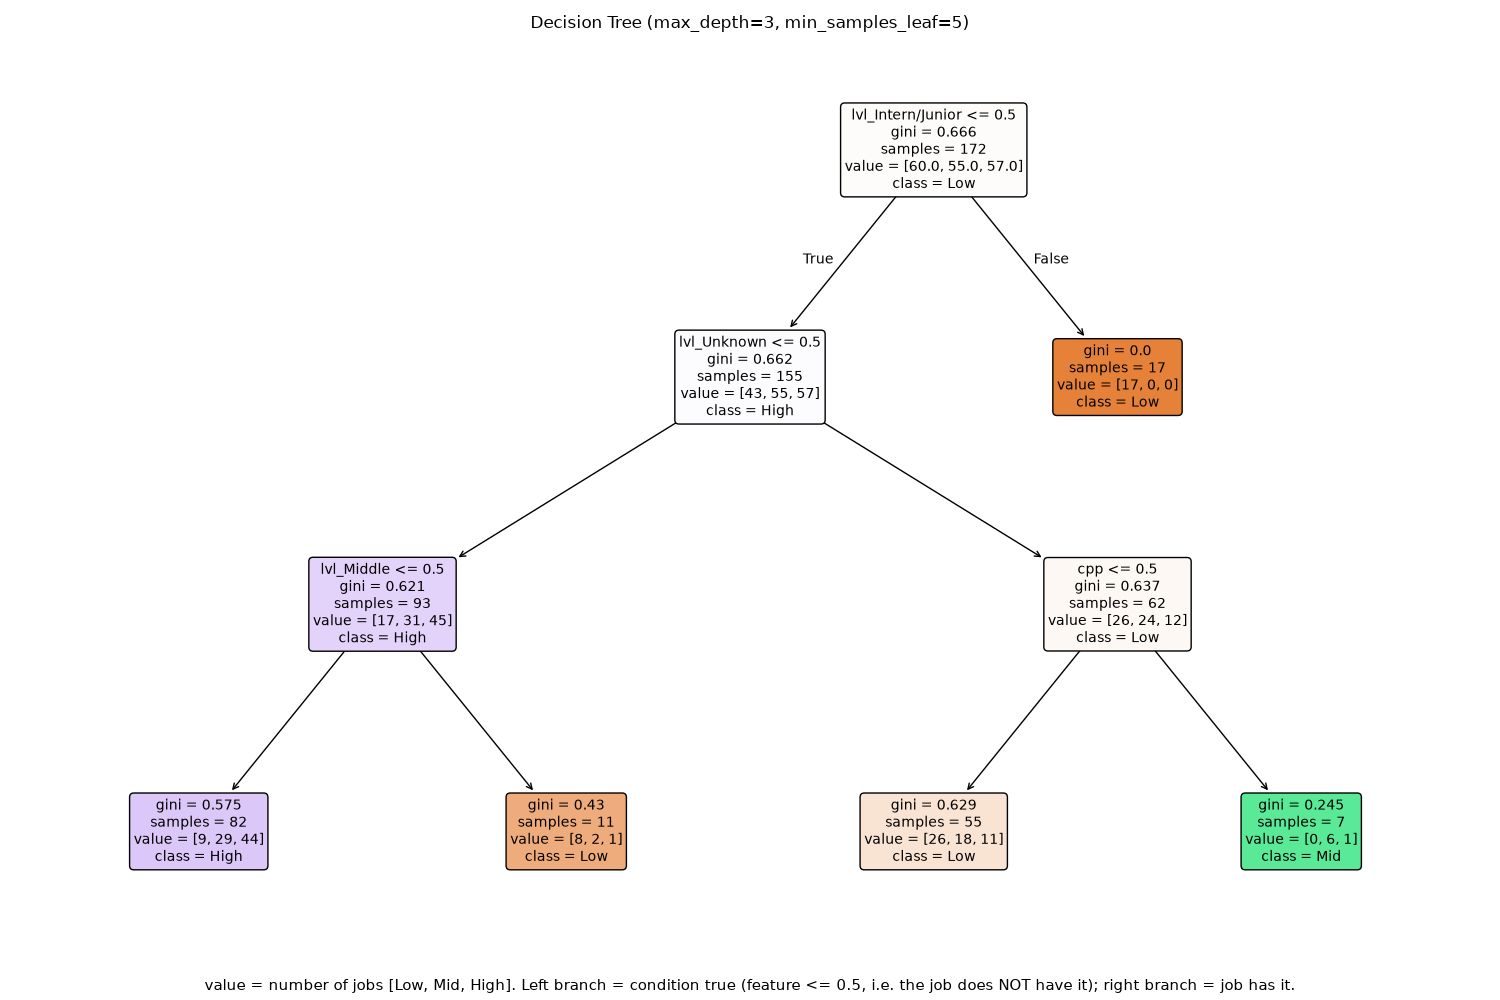

Thành phần nhóm Intern/Junior trong tin có lương:


,Số tin,Trung vị (triệu),Thấp nhất,Cao nhất
level,,,,
Intern,14,4.1,2.3,9.0
Fresher,1,3.6,3.6,3.6
Junior,2,15.7,12.0,19.3


In [18]:
display(Image(filename=str(ROOT / "reports" / "figures" / "tree_viz.png"), width=900))
breakdown = clf.intern_junior_breakdown(raw_jobs)
print("Thành phần nhóm Intern/Junior trong tin có lương:")
breakdown

**Đọc kết quả:** cây vượt baseline (CI ở trên không chứa baseline) — có tín hiệu thật. Cấp bậc là feature quan trọng nhất. ⚠️ Nhánh `Intern/Junior` chủ yếu là **thực tập sinh** (phụ cấp) — không diễn giải thành "Junior lương thấp". Lớp Mid khó tách nhất.

## 6. Thiên lệch: tin có lương vs không lương

Mô hình Q3 chỉ học từ tin có lương. So sánh 2 nhóm để biết kết luận áp dụng được tới đâu (chi tiết: `reports/bias_analysis.md`).

In [19]:
from scipy.stats import chi2_contingency

has = jobs["has_salary"]
loc_cmp = compare_groups(jobs[["loc_hcm", "loc_hn", "loc_dn", "loc_other"]], has)
skill_cmp = compare_groups(skills, has, min_total=5)
level_p = chi2_contingency(pd.crosstab(jobs["level_group"], has))[1]

bias_md = (ROOT / "reports" / "bias_analysis.md").read_text(encoding="utf-8")
assert f"p-value = {level_p:.4e}" in bias_md, "Không khớp reports/bias_analysis.md"
print("✓ khớp reports/bias_analysis.md")
n_sig_skills = int((skill_cmp["adj_p_value"] < 0.05).sum())
print(f"Kỹ năng khác biệt có ý nghĩa (BH adj p < 0,05): {n_sig_skills}/{len(skill_cmp)}")
print(f"Cấp bậc: chi-square p = {level_p:.3f}")
KEY["bias"] = {
    "n_with_salary": int(has.sum()), "n_without_salary": int((~has).sum()),
    "n_skills_tested": int(len(skill_cmp)), "n_skills_significant": n_sig_skills,
    "level_chi2_p": round(float(level_p), 3),
    "location": {c: {"pct_with_salary": round(float(r.iloc[0]) * 100, 1),
                     "pct_without_salary": round(float(r.iloc[1]) * 100, 1),
                     "adj_p": round(float(r["adj_p_value"]), 4)} for c, r in loc_cmp.iterrows()},
}
loc_cmp.round(4)

✓ khớp reports/bias_analysis.md
Kỹ năng khác biệt có ý nghĩa (BH adj p < 0,05): 0/100
Cấp bậc: chi-square p = 0.060


,Có lương (%),Không lương (%),Chênh lệch (%),p_value,adj_p_value
loc_hcm,0.4767,0.6647,-0.1880,0.0000,0.0001
loc_hn,0.5174,0.3857,0.1318,0.0032,0.0063
loc_dn,0.0407,0.0523,-0.0116,0.6855,0.9140
loc_other,0.0058,0.0039,0.0019,1.0000,1.0000


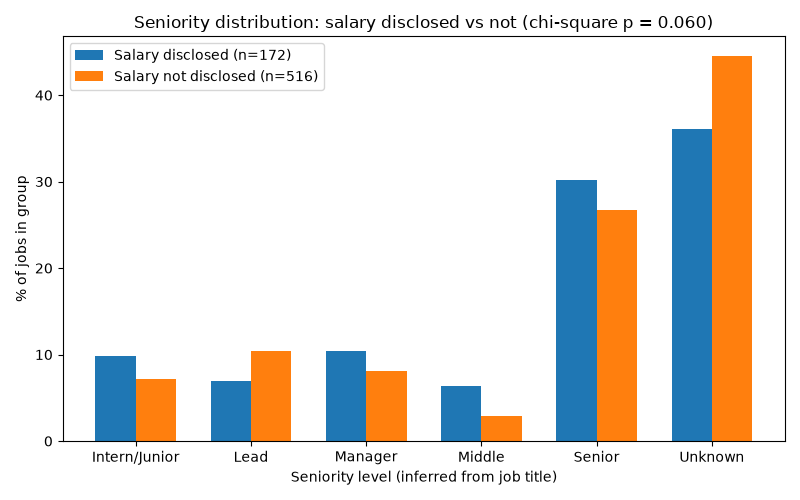

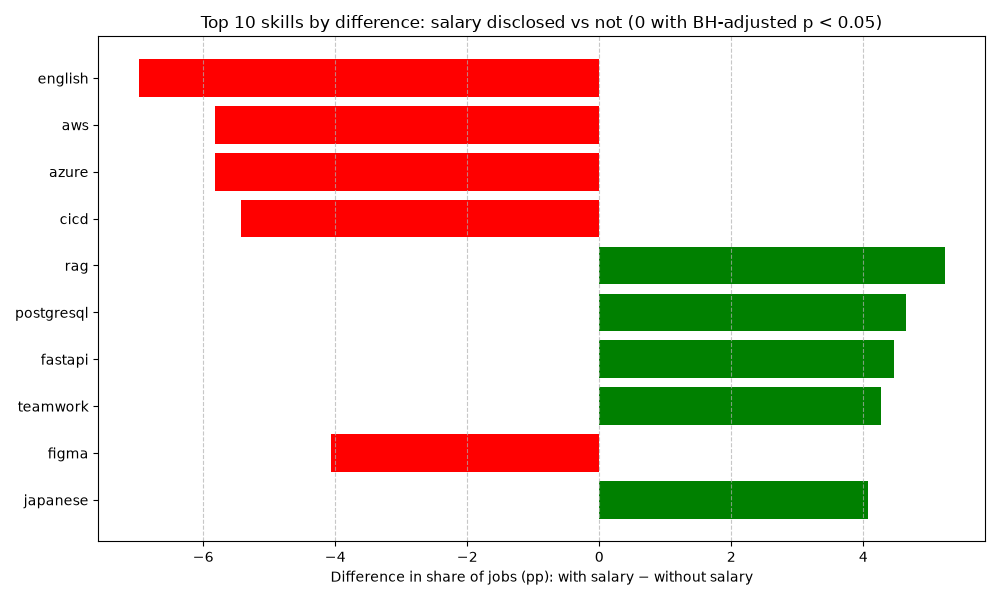

In [20]:
for name in ["bias_levels.png", "bias_skills.png"]:
    display(Image(filename=str(ROOT / "reports" / "figures" / name), width=750))

## 7. Số liệu cho slide → `reports/key_numbers.json`

In [21]:
out = ROOT / "reports" / "key_numbers.json"
out.write_text(json.dumps(KEY, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print(f"Đã ghi {out.relative_to(ROOT)}")
print(json.dumps(KEY, ensure_ascii=False, indent=2, default=str)[:3000])

Đã ghi reports/key_numbers.json
{
  "data": {
    "n_jobs": 688,
    "crawl_date": "2026-09-29",
    "n_jobs_with_skills": 677,
    "n_skills_in_matrix": 100,
    "n_jobs_clustered": 548,
    "n_jobs_with_salary": 172,
    "pct_with_salary": 25.0,
    "posted_from": "2026-08-10",
    "posted_to": "2026-09-29",
    "skill_dict_coverage_a7_pct": 72.6
  },
  "eda": {
    "top10_skills_pct": {
      "english": 54.7,
      "communication": 41.7,
      "api": 36.0,
      "cicd": 31.4,
      "git": 28.6,
      "sql": 28.5,
      "aws": 27.6,
      "agile": 25.6,
      "python": 25.4,
      "docker": 23.0
    },
    "salary_median_million_vnd": 38.7,
    "currency_counts": {
      "USD": 151,
      "VND": 21
    },
    "pct_level_unknown": 42.4,
    "location_counts": {
      "loc_hcm": 425,
      "loc_hn": 288,
      "loc_dn": 34,
      "loc_other": 3
    }
  },
  "q1_rules": {
    "n_train": 473,
    "n_test": 204,
    "min_support": 0.1,
    "n_rules": 35,
    "top_rules_hold_on_test": "9/1

## 8. Kết luận & hạn chế

Sinh từ `KEY` để không có số gõ tay.

In [22]:
d, q1, q2, q3, b = KEY["data"], KEY["q1_rules"], KEY["q2_clustering"], KEY["q3_tree"], KEY["bias"]
top_rules = "; ".join(r["Luật"] for r in q1["top_rules"][:3])
top_feat = ", ".join(list(q3["feature_importance"])[:3])
loc = b["location"]
display(Markdown(f"""
**Kết luận**

1. **Q1 — kỹ năng đi kèm:** {q1["n_rules"]} luật (min_support {q1["min_support"]}); mạnh nhất: {top_rules}.
   {q1["top_rules_hold_on_test"]} luật top vẫn đạt ngưỡng trên tin mới (test).
2. **Q2 — nhóm nghề:** k = {q2["k"]}, silhouette {q2["silhouette"]}; cụm lớn nhất chiếm {q2["pct_jobs_in_largest_cluster"]}% số tin
   → tổ hợp kỹ năng **không tách thành nhóm nghề rõ ràng**; purity {q2["purity"]} so với baseline {q2["baseline_purity"]}.
3. **Q3 — lương:** accuracy {q3["accuracy"]} (95% CI {q3["accuracy_ci95"][0]}–{q3["accuracy_ci95"][1]}) so với baseline {q3["baseline"]};
   feature quan trọng nhất: {top_feat}. Recall lớp Mid chỉ {q3["recall_by_class"]["Mid"]}.

**Hạn chế**

- {d["n_jobs"]} tin, 1 snapshot ngày {d["crawl_date"]} — chỉ tin còn tuyển (đăng {d["posted_from"]} → {d["posted_to"]}).
- Chỉ {d["pct_with_salary"]}% tin có lương (JSON-LD); nhóm có lương ở Hà Nội {loc["loc_hn"]["pct_with_salary"]}% so với
  {loc["loc_hn"]["pct_without_salary"]}% ở nhóm không lương (adj p = {loc["loc_hn"]["adj_p"]}) → kết luận Q3 nghiêng về Hà Nội.
- Từ điển kỹ năng phủ {d["skill_dict_coverage_a7_pct"]}% (A7, ngưỡng 80%): sót công cụ mới/ngách và dạng "APIs".
- {KEY["eda"]["pct_level_unknown"]}% tin không suy được cấp bậc từ tiêu đề; nhóm `Intern/Junior` có lương chủ yếu là thực tập sinh.
- Lương: tỷ giá cố định, không phân biệt gross/net, tin chỉ có 1 cận dùng cận đó làm lương đại diện.
"""))


**Kết luận**

1. **Q1 — kỹ năng đi kèm:** 35 luật (min_support 0.1); mạnh nhất: spring → java; kubernetes → docker; gcp → aws.
   9/10 luật top vẫn đạt ngưỡng trên tin mới (test).
2. **Q2 — nhóm nghề:** k = 4, silhouette 0.048; cụm lớn nhất chiếm 73.0% số tin
   → tổ hợp kỹ năng **không tách thành nhóm nghề rõ ràng**; purity 0.334 so với baseline 0.208.
3. **Q3 — lương:** accuracy 0.529 (95% CI 0.453–0.605) so với baseline 0.349;
   feature quan trọng nhất: lvl_Intern/Junior, lvl_Middle, lvl_Unknown. Recall lớp Mid chỉ 0.236.

**Hạn chế**

- 688 tin, 1 snapshot ngày 2026-09-29 — chỉ tin còn tuyển (đăng 2026-08-10 → 2026-09-29).
- Chỉ 25.0% tin có lương (JSON-LD); nhóm có lương ở Hà Nội 51.7% so với
  38.6% ở nhóm không lương (adj p = 0.0063) → kết luận Q3 nghiêng về Hà Nội.
- Từ điển kỹ năng phủ 72.6% (A7, ngưỡng 80%): sót công cụ mới/ngách và dạng "APIs".
- 42.4% tin không suy được cấp bậc từ tiêu đề; nhóm `Intern/Junior` có lương chủ yếu là thực tập sinh.
- Lương: tỷ giá cố định, không phân biệt gross/net, tin chỉ có 1 cận dùng cận đó làm lương đại diện.
